# Chocolate Ratings Analysis

## 3. Exploratory Data Analysis

This notebook explores the cleaned chocolate ratings dataset through the following questions:

1. How are chocolate ratings distributed?
2. Which cocoa percentages are most common?
3. Is cocoa percentage associated with rating?
4. How do review counts and average ratings vary by year?
5. Which companies have the highest average ratings among those with at least 10 reviews?
6. Which companies and company locations are most represented?
7. Which broad bean origins and bean types are most represented?

The findings describe the reviewed chocolates in this dataset.
They should not be interpreted as global production statistics or causal relationships.

In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
project_root = Path.cwd()

if not (project_root / "data" / "processed" / "chocolate_clean.csv").exists():
    project_root = project_root.parent

DATA_PATH = project_root / "data" / "processed" / "chocolate_clean.csv"

if not DATA_PATH.exists():
    raise FileNotFoundError(f"Cleaned dataset not found: {DATA_PATH}")

df = pd.read_csv(DATA_PATH)

df.head()

,company,specific_bean_origin,review_date,cocoa_percent,company_location,rating,bean_type,broad_bean_origin
0,A. Morin,Agua Grande,2016,63.0,France,3.75,Blend,Sao Tome
1,A. Morin,Kpime,2015,70.0,France,2.75,Blend,Togo
2,A. Morin,Atsane,2015,70.0,France,3.00,Blend,Togo
3,A. Morin,Akata,2015,70.0,France,3.50,Blend,Togo
4,A. Morin,Quilla,2015,70.0,France,3.50,Blend,Peru


In [3]:
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

df.info()

Rows: 1,795
Columns: 8
<class 'pandas.DataFrame'>
RangeIndex: 1795 entries, 0 to 1794
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   company               1795 non-null   str    
 1   specific_bean_origin  1795 non-null   str    
 2   review_date           1795 non-null   int64  
 3   cocoa_percent         1795 non-null   float64
 4   company_location      1795 non-null   str    
 5   rating                1795 non-null   float64
 6   bean_type             1795 non-null   str    
 7   broad_bean_origin     1795 non-null   str    
dtypes: float64(2), int64(1), str(5)
memory usage: 112.3 KB


In [4]:
required_columns = [
    "company",
    "review_date",
    "cocoa_percent",
    "company_location",
    "rating",
    "bean_type",
    "broad_bean_origin",
]

assert set(required_columns).issubset(df.columns), "Required columns are missing."

assert df[required_columns].notna().all().all(), (
    "Missing values found in analysis columns."
)

assert df["cocoa_percent"].between(0, 100, inclusive="right").all(), (
    "Cocoa percentages must be greater than 0 and no greater than 100."
)

assert df.duplicated().sum() == 0, "Duplicate rows found."

print("Basic data validation passed.")

Basic data validation passed.


## 1. Rating Distribution

We first examine the typical rating and the frequency of each observed score.

Because ratings take discrete values, a frequency bar chart is used.

In [5]:
df["rating"].describe()

count    1795.000000
mean        3.185933
std         0.478062
min         1.000000
25%         2.875000
50%         3.250000
75%         3.500000
max         5.000000
Name: rating, dtype: float64

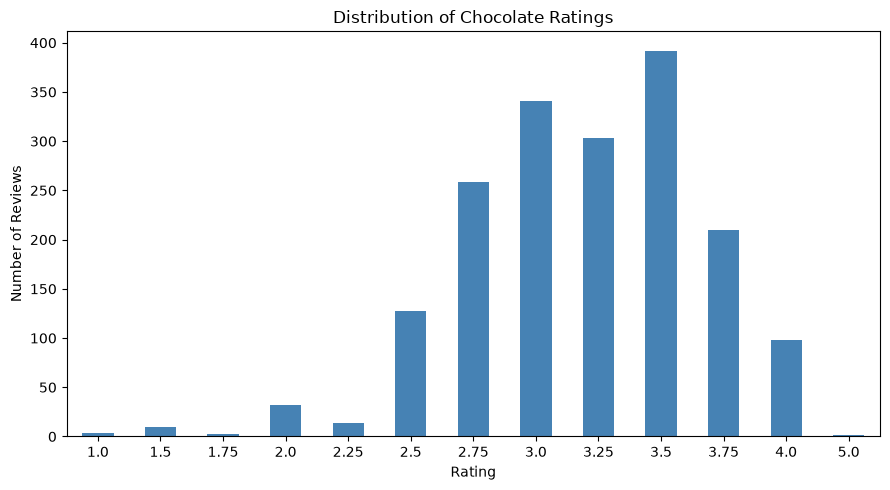

In [6]:
rating_counts = df["rating"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(9, 5))

rating_counts.plot.bar(ax=ax, color="steelblue")

ax.set_title("Distribution of Chocolate Ratings")
ax.set_xlabel("Rating")
ax.set_ylabel("Number of Reviews")
ax.tick_params(axis="x", rotation=0)

fig.tight_layout()
plt.show()

In [7]:
print(f"Mean rating: {df['rating'].mean():.3f}")
print(f"Median rating: {df['rating'].median():.2f}")
print(f"Observed rating range: {df['rating'].min():.2f}–{df['rating'].max():.2f}")

Mean rating: 3.186
Median rating: 3.25
Observed rating range: 1.00–5.00


### Findings

The mean rating is approximately **3.186**, and the median is **3.25**.

The middle 50% of ratings fall between **2.875 and 3.50**.
Observed ratings range from **1.00 to 5.00**.

These statistics describe the distribution of review scores in this dataset.

## 2. Cocoa Percentage Distribution

We examine the range of cocoa percentages and identify the most frequently reviewed concentrations.

In [8]:
df["cocoa_percent"].describe()

count    1795.000000
mean       71.698329
std         6.323118
min        42.000000
25%        70.000000
50%        70.000000
75%        75.000000
max       100.000000
Name: cocoa_percent, dtype: float64

In [9]:
cocoa_counts = df["cocoa_percent"].value_counts()

top_cocoa_percentages = (
    cocoa_counts
    .head(10)
    .rename_axis("cocoa_percent")
    .reset_index(name="number_of_reviews")
)

top_cocoa_percentages

,cocoa_percent,number_of_reviews
0,70.0,672
1,75.0,222
2,72.0,189
3,65.0,78
4,80.0,72
5,74.0,50
6,68.0,47
7,60.0,43
8,73.0,40
9,85.0,36


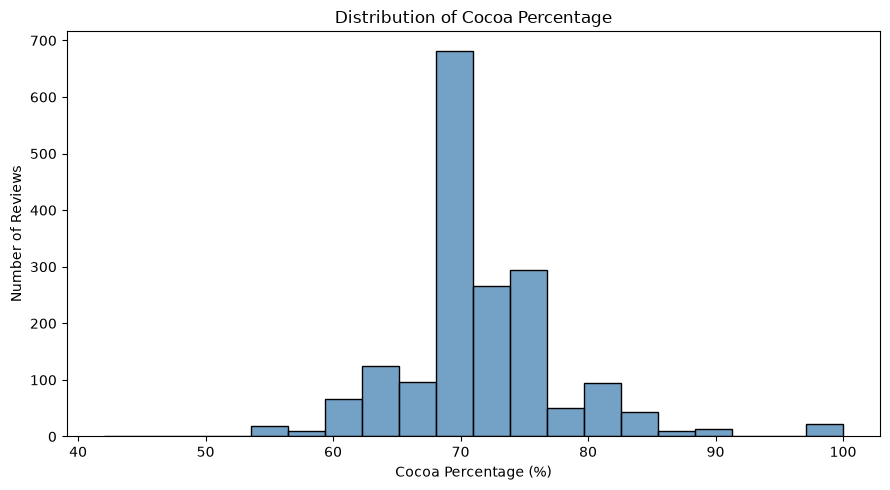

In [10]:
fig, ax = plt.subplots(figsize=(9, 5))

sns.histplot(
    data=df,
    x="cocoa_percent",
    bins=20,
    color="steelblue",
    ax=ax,
)

ax.set_title("Distribution of Cocoa Percentage")
ax.set_xlabel("Cocoa Percentage (%)")
ax.set_ylabel("Number of Reviews")

fig.tight_layout()
plt.show()

### Findings

The mean cocoa percentage is approximately **71.70%**, while the median is **70%**.

The most common cocoa percentage is **70%**, appearing in **672 reviews**, or approximately **37.4%** of the dataset.

Observed cocoa percentages range from **42% to 100%**.

## 3. Cocoa Percentage and Rating

We investigate whether cocoa percentage is associated with chocolate rating.

Pearson correlation summarizes the linear association.
The plot also helps reveal patterns that a single correlation coefficient may miss.

In [11]:
cocoa_rating_correlation = df["cocoa_percent"].corr(df["rating"])

print(f"Pearson correlation: {cocoa_rating_correlation:.3f}")

Pearson correlation: -0.165


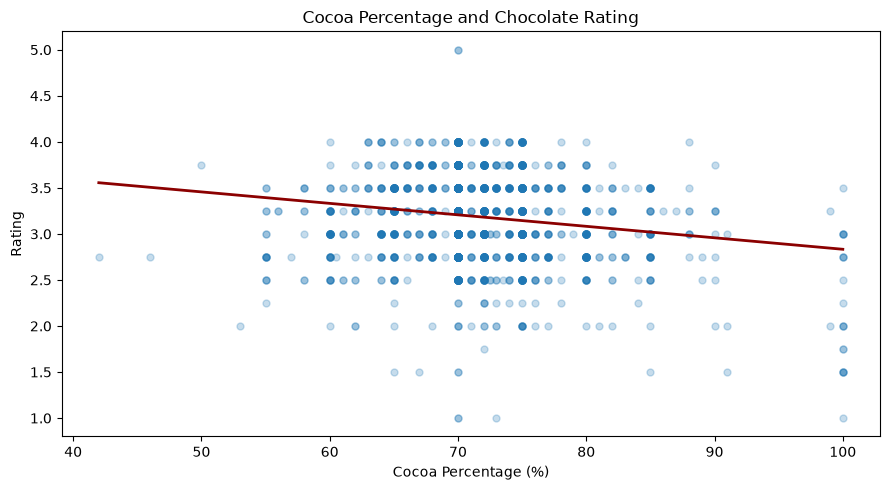

In [12]:
fig, ax = plt.subplots(figsize=(9, 5))

sns.regplot(
    data=df,
    x="cocoa_percent",
    y="rating",
    ci=None,
    scatter_kws={"alpha": 0.25, "s": 25},
    line_kws={"color": "darkred", "linewidth": 2},
    ax=ax,
)

ax.set_title("Cocoa Percentage and Chocolate Rating")
ax.set_xlabel("Cocoa Percentage (%)")
ax.set_ylabel("Rating")

fig.tight_layout()
plt.show()

In [13]:
common_percentages = cocoa_counts.head(10).index

cocoa_rating_stats = (
    df.loc[df["cocoa_percent"].isin(common_percentages)]
    .groupby("cocoa_percent")
    .agg(
        average_rating=("rating", "mean"),
        number_of_reviews=("rating", "size"),
    )
    .sort_index()
)

cocoa_rating_stats.round(3)

,average_rating,number_of_reviews
cocoa_percent,,
60.0,3.006,43
65.0,3.170,78
68.0,3.287,47
70.0,3.276,672
72.0,3.190,189
73.0,3.175,40
74.0,3.235,50
75.0,3.178,222
80.0,3.028,72


### Findings

The Pearson correlation between cocoa percentage and rating is approximately **−0.165**, indicating a weak negative linear association in this dataset.

Higher cocoa percentages do not consistently correspond to higher ratings.

This association does not establish causation. The analysis does not control for other product characteristics, and Pearson correlation may miss nonlinear patterns.

## 4. Review Activity and Average Ratings Over Time

We examine review counts and average ratings together.

Review counts provide context for interpreting annual averages.
Each year may contain a different mix of companies and chocolate products.

In [14]:
yearly_stats = (
    df.groupby("review_date")
    .agg(
        number_of_reviews=("rating", "size"),
        average_rating=("rating", "mean"),
    )
    .sort_index()
)

yearly_stats.round(3)

,number_of_reviews,average_rating
review_date,,
2006,72,3.125
2007,77,3.162
2008,93,2.995
2009,123,3.073
2010,111,3.149
2011,165,3.256
2012,195,3.178
2013,184,3.197
2014,247,3.189


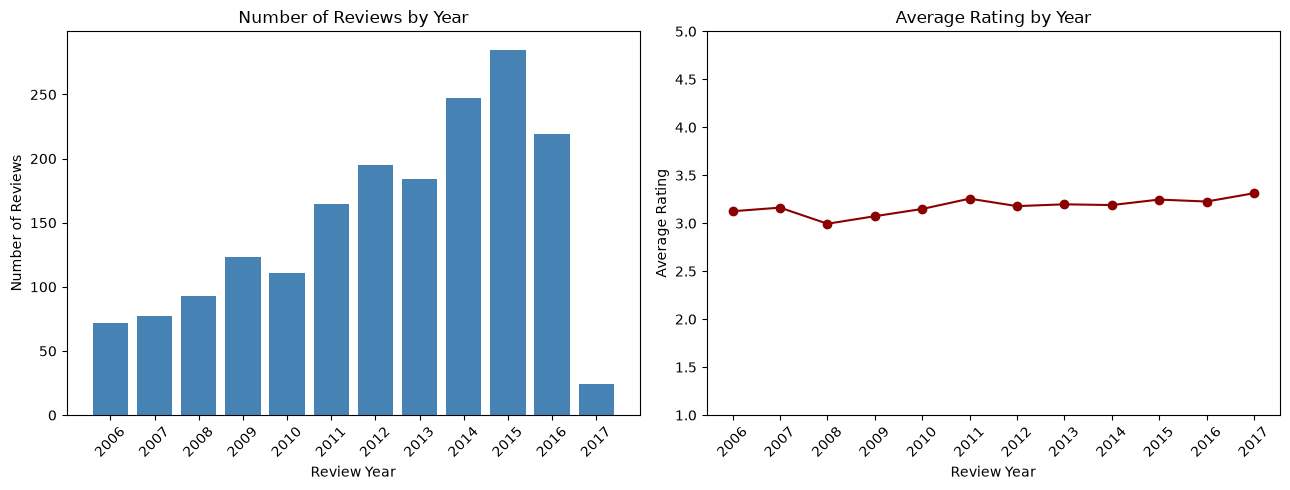

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].bar(
    yearly_stats.index,
    yearly_stats["number_of_reviews"],
    color="steelblue",
)

axes[0].set_title("Number of Reviews by Year")
axes[0].set_xlabel("Review Year")
axes[0].set_ylabel("Number of Reviews")

axes[1].plot(
    yearly_stats.index,
    yearly_stats["average_rating"],
    marker="o",
    color="darkred",
)

axes[1].set_title("Average Rating by Year")
axes[1].set_xlabel("Review Year")
axes[1].set_ylabel("Average Rating")
axes[1].set_ylim(1, 5)

for ax in axes:
    ax.set_xticks(yearly_stats.index)
    ax.tick_params(axis="x", rotation=45)

fig.tight_layout()
plt.show()

### Findings

The dataset covers review years from **2006 to 2017**.

Review counts vary substantially. The largest count occurs in **2015**, with **285 reviews**, while **2017** contains only **24 reviews**.

Annual average ratings range from approximately **2.995 in 2008** to **3.313 in 2017**.

The small number of reviews in 2017 limits comparisons with more heavily represented years.
Differences in annual averages may reflect changes in the reviewed products and companies rather than changes in overall chocolate quality.

## 5. Company Ratings

Company averages can be misleading when based on very few reviews.

We therefore calculate both average rating and review count, then compare companies with at least 10 reviews.

This threshold is an exploratory choice. It reduces the influence of very small samples but does not guarantee a reliable ranking.

In [16]:
company_stats = (
    df.groupby("company")
    .agg(
        average_rating=("rating", "mean"),
        number_of_reviews=("rating", "size"),
    )
    .reset_index()
)

company_stats["number_of_reviews"].describe()

count    416.000000
mean       4.314904
std        4.891534
min        1.000000
25%        1.000000
50%        3.000000
75%        5.000000
max       47.000000
Name: number_of_reviews, dtype: float64

In [17]:
MIN_REVIEWS = 10

eligible_companies = (
    company_stats.loc[
        company_stats["number_of_reviews"] >= MIN_REVIEWS
    ]
    .sort_values(
        ["average_rating", "number_of_reviews", "company"],
        ascending=[False, False, True],
    )
    .reset_index(drop=True)
)

top_companies = eligible_companies.head(10).copy()

print(f"Total companies: {len(company_stats)}")
print(f"Companies with at least {MIN_REVIEWS} reviews: {len(eligible_companies)}")

top_companies.round(3)

Total companies: 416
Companies with at least 10 reviews: 40


,company,average_rating,number_of_reviews
0,Amedei,3.846,13
1,Idilio (Felchlin),3.775,10
2,Soma,3.585,47
3,Arete,3.534,22
4,"Smooth Chocolator, The",3.516,16
5,Duffy's,3.500,13
6,Domori,3.477,22
7,Pierre Marcolini,3.464,14
8,Marou,3.450,10
9,Bonnat,3.435,27


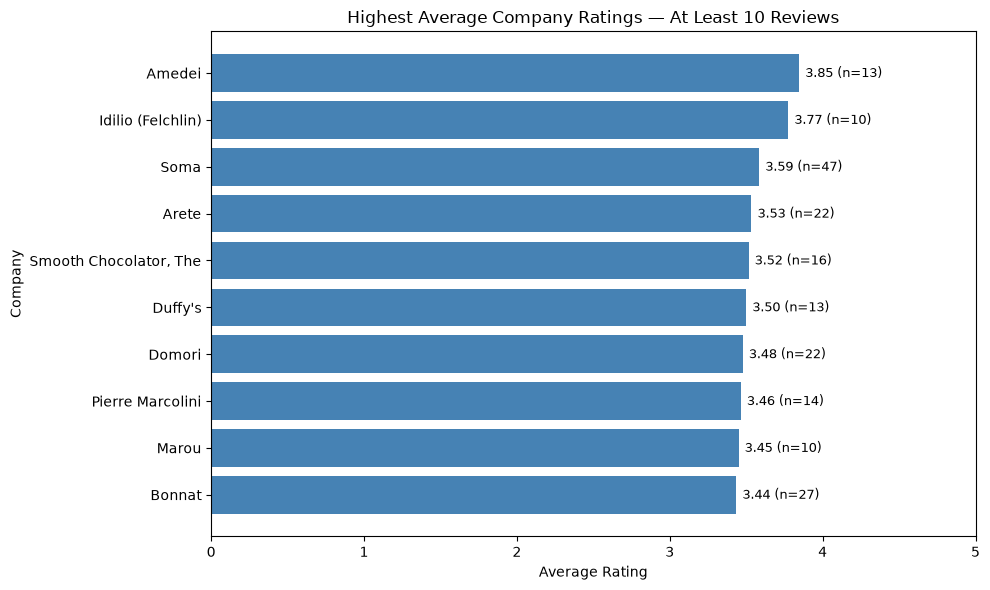

In [18]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.barh(
    top_companies["company"],
    top_companies["average_rating"],
    color="steelblue",
)

ax.invert_yaxis()

for position, row in enumerate(top_companies.itertuples(index=False)):
    ax.text(
        row.average_rating + 0.04,
        position,
        f"{row.average_rating:.2f} (n={row.number_of_reviews})",
        va="center",
        fontsize=9,
    )

ax.set_xlim(0, 5)
ax.set_title(f"Highest Average Company Ratings — At Least {MIN_REVIEWS} Reviews")
ax.set_xlabel("Average Rating")
ax.set_ylabel("Company")

fig.tight_layout()
plt.show()

### Findings

Of the **416 companies** in the dataset, **40** have at least **10 reviews**.

Among these eligible companies, **Amedei** has the highest average rating at approximately **3.846**, based on **13 reviews**.

This ranking describes reviewed products in the dataset. It does not establish which company is universally the best.

The review counts differ across companies, and changing the minimum-review threshold may change the ranking.

## 6. Company and Location Representation

We now examine which companies and company locations appear most frequently.

Review frequency measures representation in this dataset.
It does not measure market share, sales, or production volume.

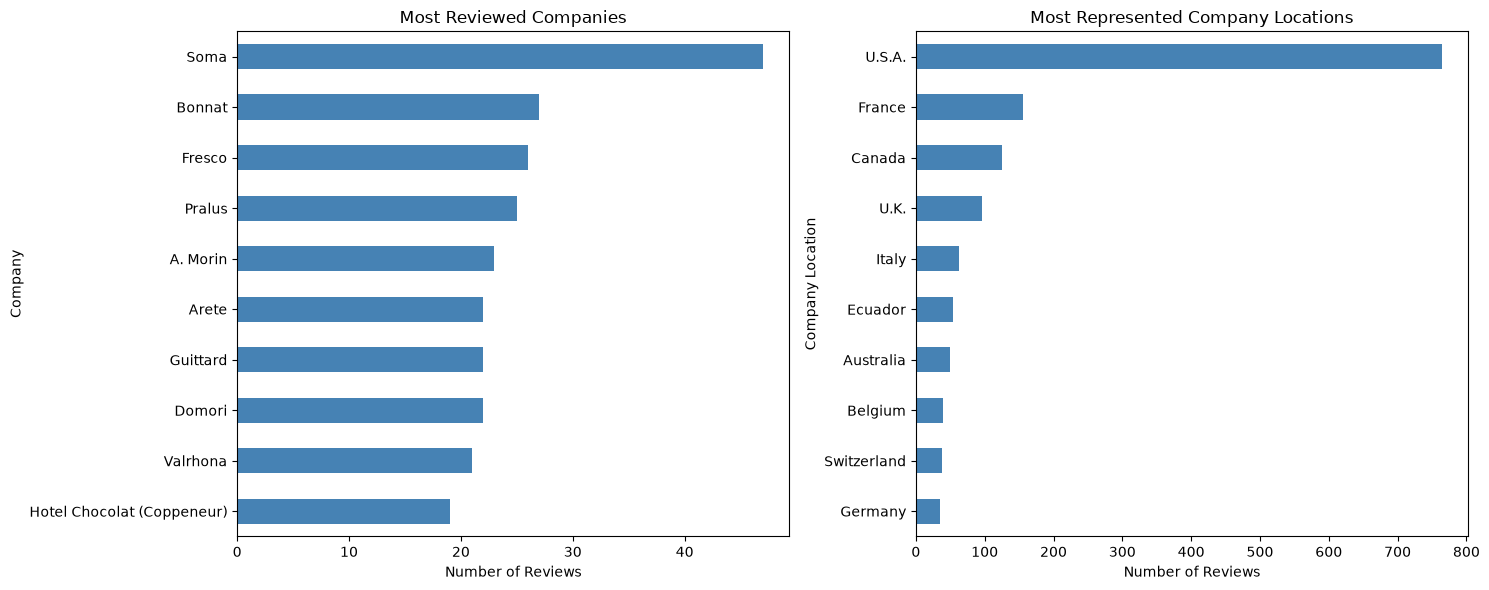

In [19]:
most_reviewed_companies = df["company"].value_counts().head(10)
top_locations = df["company_location"].value_counts().head(10)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

most_reviewed_companies.sort_values().plot.barh(
    ax=axes[0],
    color="steelblue",
)

axes[0].set_title("Most Reviewed Companies")
axes[0].set_xlabel("Number of Reviews")
axes[0].set_ylabel("Company")

top_locations.sort_values().plot.barh(
    ax=axes[1],
    color="steelblue",
)

axes[1].set_title("Most Represented Company Locations")
axes[1].set_xlabel("Number of Reviews")
axes[1].set_ylabel("Company Location")

fig.tight_layout()
plt.show()

### Findings

The most represented company location is **U.S.A.**, with **764 reviews**, followed by **France** with **156** and **Canada** with **125**.

These counts refer to the locations of companies associated with reviewed chocolates.
They do not describe the origin of the cacao beans or global chocolate production.

## 7. Broad Bean Origin

We examine the most frequently recorded broad bean origins.

The column contains geographic labels and other categories.
These labels are retained as recorded and should not all be interpreted as individual countries.

Unknown origins are reported separately.

Reviews with unknown broad bean origin: 1


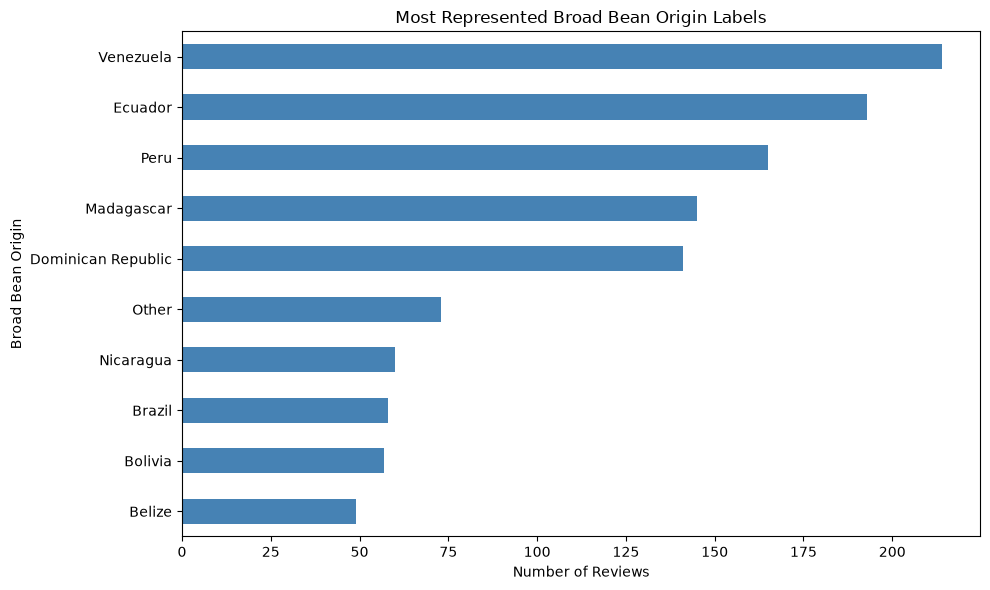

In [20]:
unknown_origin_count = df["broad_bean_origin"].eq("Unknown").sum()

top_origins = (
    df.loc[
        df["broad_bean_origin"] != "Unknown",
        "broad_bean_origin",
    ]
    .value_counts()
    .head(10)
)

print(f"Reviews with unknown broad bean origin: {unknown_origin_count}")

fig, ax = plt.subplots(figsize=(10, 6))

top_origins.sort_values().plot.barh(
    ax=ax,
    color="steelblue",
)

ax.set_title("Most Represented Broad Bean Origin Labels")
ax.set_xlabel("Number of Reviews")
ax.set_ylabel("Broad Bean Origin")

fig.tight_layout()
plt.show()

### Findings

The most frequently recorded broad bean origin labels are **Venezuela** with **214 reviews**, **Ecuador** with **193**, and **Peru** with **165**.

One review has an unknown broad bean origin.

These counts describe the origins recorded for reviewed chocolates and do not measure cacao production volume.

## 8. Bean Type Representation

Bean type labels include individual varieties, combinations, and the category "Blend".

We inspect their frequencies without treating the labels as a standardized classification or inferring quality differences from frequency alone.

In [21]:
bean_type_counts = df["bean_type"].value_counts()

bean_type_summary = pd.DataFrame({
    "number_of_reviews": bean_type_counts,
    "share_percent": bean_type_counts / len(df) * 100,
})

bean_type_summary.index.name = "bean_type"

bean_type_summary.head(15).round(2)

,number_of_reviews,share_percent
bean_type,,
Blend,929,51.75
Trinitario,419,23.34
Criollo,153,8.52
Forastero,87,4.85
Forastero (Nacional),52,2.90
"Criollo, Trinitario",39,2.17
Forastero (Arriba),37,2.06
Criollo (Porcelana),10,0.56
"Trinitario, Criollo",9,0.50


### Findings

"Blend" is the most common recorded bean type label, appearing in **929 reviews**, or approximately **51.8%** of the dataset.

"Trinitario" and "Criollo" are the next most frequent exact labels, with **419** and **153 reviews**, respectively.

Combined labels such as "Criollo, Trinitario" remain separate categories.
These frequencies do not establish differences in chocolate quality between bean types.

## Key Findings

- The dataset contains **1,795 reviews**, with a mean rating of approximately **3.186** and a median of **3.25**.
- **70% cocoa** is the most common concentration, appearing in **672 reviews**.
- Cocoa percentage and rating show a **weak negative linear association**: Pearson correlation is approximately **−0.165**.
- Review activity varies substantially by year. **2015** has the most reviews, while **2017** contains only **24**.
- Among companies with at least **10 reviews**, **Amedei** has the highest average rating: approximately **3.846**, based on **13 reviews**.
- **U.S.A.** is the most represented company location.
- **Venezuela** is the most frequently recorded broad bean origin label.
- **Blend** is the most common recorded bean type label.

## Limitations

- The dataset represents reviewed chocolates rather than a random sample of the global chocolate market.
- Company and year comparisons involve different numbers and mixtures of reviewed products.
- The minimum of 10 reviews is an exploratory threshold, not a guarantee of ranking reliability.
- Correlations describe associations and do not establish causation.
- Bean type and origin labels include combined and broad categories.

## Next Steps

Further analysis could examine whether the cocoa-rating relationship differs across companies or bean origins.

Any additional comparisons should consider sample size and category consistency.